In [1]:
import os
import sys
import datetime as dt

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

# import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

# from utils import haversine, hp_mods, get_nn_lon_lat_index

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [37]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)

In [38]:
ds.pr

<xarray.DataArray 'pr' (time: 9745, cell: 12288)> Size: 479MB
dask.array<open_dataset-pr, shape=(9745, 12288), dtype=float32, chunksize=(64, 12288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
    crs      int64 8B 0
  * cell     (cell) int64 98kB 0 1 2 3 4 5 ... 12283 12284 12285 12286 12287
    lat      (cell) float64 98kB 1.194 2.388 2.388 ... -2.388 -2.388 -1.194
    lon      (cell) float64 98kB 45.0 46.41 43.59 45.0 ... 316.4 313.6 315.0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 4, 203]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['stratiform_rainfall_flux', 'stratiform_snowfall_flux']
    notes:          Combined rain and snow. Hourly mean - time index shifted ...
    grid_mapping:   crs

<Figure size 640x480 with 0 Axes>

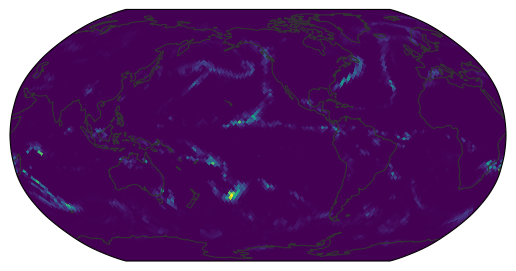

In [39]:
egh.healpix_show(ds.pr.isel(time=4))


## Onset Period analysis

Marcia's technique takes the following steps:
1. Butterworth filter precipitation timeseries with a 60-day window Pr_{60}
2. Take time derivative of Pr_{60}
3. Identify periods where Pr_{60} and dPr_{60}/dt are positive for 30 days or more.
4. ??? Refine onset ??? 

In [59]:
import OnsetPeriod_toolbox as optb

fwin = 60  # size of the butterworth filtering window
minlen = 30  # minimum length of the onset period envelope
pp = ds.pr.isel(cell=10).resample(time="1D").mean()


def onset_period(
    pp, deltat=pp.time.dt.dayofyear[0].item(), max_dry_frac_rainfall=0.3, refine=False
):
    # step 1
    flt = optb.butterworth(pp, fwin)

    # step 2
    grd = np.gradient(flt)

    # step 3
    rny = xr.where(((flt > 0) & (grd > 0)), 1, 0)
    fd, lns = optb.FindOnsetPeriods(rny, minlen)
    
    #### NOT SURE WHETHER TO REMOVE 
    # #remove first onset period if it starts at the very beginning of the sim
    # if fd and fd[0] == 0:
    #     fd = fd[1:]
    #     lns = lns[1:]

    if refine:
        for ons_ix in range(len(fd)):
            this_pp = pp[fd[ons_ix] : fd[ons_ix] + lns[ons_ix]]
            fd[ons_ix], lns[ons_ix] = RefineOns(
                pp, pp.mean(dim="time") * max_dry_frac_rainfall
            )
    # shift back to day of year rather than day of simulation
    first_days = np.array(fd) + deltat
    last_days = np.array(fd) + np.array(lns) + deltat

    return first_days, last_days

Text(0.5, 1.0, '(71.5909090909091,57.39952353962293)')

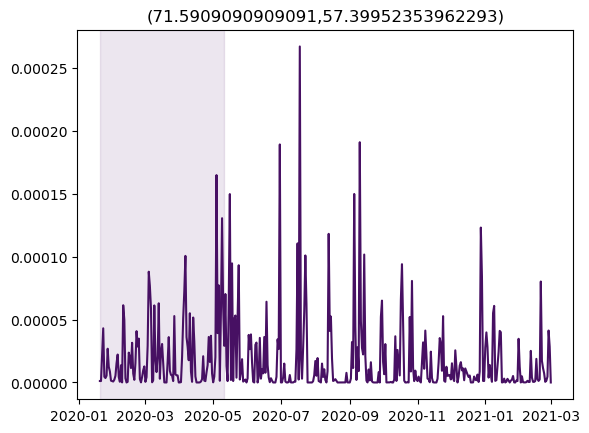

In [65]:
for cell_ix in range(len(ds.pr.cell[:20])):
    # cell_ix=493
    plt.figure()
    color=plt.cm.viridis(cell_ix/len(ds.pr.cell))
    pp = ds.pr.isel(cell=cell_ix).resample(time="1D").mean()
    fds, lds = onset_period(pp,refine=False)

    plt.plot(pp.time, pp, color=color)
    [
        plt.axvspan(
            dt.datetime(2020,1,1)+dt.timedelta(days=int(fds[ix])-1),
            dt.datetime(2020,1,1)+dt.timedelta(days=int(lds[ix])-1),
            alpha=0.1,
            color=color,
        )
        for ix in range(len(fds))
    ]
    plt.title(f"({pp.lon.data},{pp.lat.data})")